# LoanLens — Baseline Machine Learning Models

The EDA showed that `Credit_History` has an unusually strong association with `Loan_Status`.

Now we move from **understanding the data** to **building a first predictive system**.

We will:

1. Define features (`X`) and target (`y`)
2. Split the data into training and test sets
3. Build a leakage-safe preprocessing pipeline
4. Train Logistic Regression
5. Evaluate the model using multiple metrics
6. Train Random Forest
7. Compare the models
8. Repeat the experiment without `Credit_History`

> **Important:** These are baseline experiments, not the final LoanLens model.


## 1. Imports

We use:
- Pandas/NumPy for data handling
- Matplotlib/Seaborn for evaluation plots
- Scikit-learn for splitting, preprocessing, models and metrics


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

sns.set_theme(style="whitegrid")


## 2. Load the dataset

This notebook is inside `notebooks/`, so the raw dataset is expected at:

`data/raw/loan_approval.csv`

We keep the raw CSV untouched.


In [2]:
project_root = Path.cwd().resolve()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_path = project_root / "data" / "raw" / "loan_approval.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {data_path}\n"
        "Make sure loan_approval.csv is inside data/raw/."
    )

df = pd.read_csv(data_path)

print(f"Loaded {len(df):,} rows and {len(df.columns)} columns.")


Loaded 3,192 rows and 14 columns.


## 3. Define X and y

In supervised learning:

- `X` = input features
- `y` = target we want to predict

For LoanLens:

`X` contains applicant/loan information, while `y` is `Loan_Status`.

We remove `Loan_ID` from `X` because it is an identifier rather than a meaningful predictive feature.


In [3]:
X = df.drop(columns=["Loan_Status", "Loan_ID"])
y = df["Loan_Status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())


X shape: (3192, 12)
y shape: (3192,)

Target distribution:
Loan_Status
Approved    1596
Rejected    1596
Name: count, dtype: int64


## 4. Identify feature groups

We separate features according to their **meaning**, not just their storage type.

### Numerical measurements
- Applicant_Income
- Coapplicant_Income
- Loan_Amount
- Loan_Term
- Age

### Categorical/binary/ordinal features
- Gender
- Married
- Dependents
- Education
- Employment_Status
- Credit_History
- Property_Area

This matters because preprocessing depends on how a feature should be interpreted.


In [4]:
numerical_features = [
    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Loan_Term",
    "Age",
]

categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Employment_Status",
    "Credit_History",
    "Property_Area",
]

print("Numerical:", numerical_features)
print("Categorical/binary:", categorical_features)


Numerical: ['Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Term', 'Age']
Categorical/binary: ['Gender', 'Married', 'Dependents', 'Education', 'Employment_Status', 'Credit_History', 'Property_Area']


## 5. Train/test split

We cannot train and evaluate on the same observations.

We split the data into:

- **Training set:** used to learn model parameters
- **Test set:** held back until evaluation

We use an 80/20 split.

`stratify=y` preserves the Approved/Rejected proportion in both sets.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows:     {len(X_test):,}")

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))


Training rows: 2,553
Test rows:     639

Training target distribution:
Loan_Status
Rejected   0.500
Approved   0.500
Name: proportion, dtype: float64

Test target distribution:
Loan_Status
Approved   0.501
Rejected   0.499
Name: proportion, dtype: float64


### Why `random_state=42`?

The split uses randomness. Setting `random_state` makes the split reproducible.

If you run the notebook tomorrow, you get the same train/test split.

The number `42` has no special ML meaning; it is simply a commonly used fixed seed.


## 6. Build the preprocessing pipeline

Our data contains missing values and categorical text.

We therefore create two preprocessing paths:

### Numerical
1. Fill missing values with the median
2. Standardize the numerical features

### Categorical
1. Fill missing values with the most frequent category
2. One-hot encode categories

The preprocessing is fitted **only on the training data** through the pipeline. This helps prevent test-set information from leaking into training.


In [6]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features),
])

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


## 7. Baseline 1 — Logistic Regression

Logistic Regression is a classification algorithm.

For each application it estimates a probability for the classes.

For example:

`P(Approved) = 0.83`

can be interpreted as an 83% model-estimated probability of the Approved class.

We start with Logistic Regression because it is relatively simple and interpretable, making it a useful baseline.


In [7]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000)),
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)
approved_index = list(
    logistic_model.named_steps["model"].classes_
).index("Approved")

logistic_probabilities = logistic_model.predict_proba(X_test)[:, approved_index]

print("Logistic Regression trained.")


Logistic Regression trained.


## 8. What did the Logistic Regression model predict?

`predict()` gives the final class.

`predict_proba()` gives probabilities for the classes.

We use the probability of the **Approved** class for ROC-AUC and later for LoanLens' probability display.


In [8]:
print("First 10 predictions:")
print(logistic_predictions[:10])

print("\nFirst 10 approval probabilities:")
print(np.round(logistic_probabilities[:10], 3))


First 10 predictions:
['Approved' 'Approved' 'Rejected' 'Approved' 'Rejected' 'Approved'
 'Rejected' 'Approved' 'Rejected' 'Approved']

First 10 approval probabilities:
[0.95  0.991 0.001 0.999 0.    0.997 0.031 0.937 0.    0.954]


## 9. Evaluate Logistic Regression

We use several metrics because no single metric tells the whole story.

- **Accuracy:** fraction of all predictions that are correct.
- **Precision:** among applications predicted Approved, how many were actually Approved?
- **Recall:** among actually Approved applications, how many did we identify?
- **F1:** harmonic mean of precision and recall.
- **ROC-AUC:** how well the model ranks positive cases above negative cases across thresholds.

Because our target is balanced, accuracy is useful, but we still report all of these.


In [9]:
def evaluate_classifier(model_name, y_true, predictions, probabilities):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, pos_label="Approved"),
        "Recall": recall_score(y_true, predictions, pos_label="Approved"),
        "F1": f1_score(y_true, predictions, pos_label="Approved"),
        "ROC-AUC": roc_auc_score(
            (y_true == "Approved").astype(int),
            probabilities
        ),
    }

logistic_results = evaluate_classifier(
    "Logistic Regression",
    y_test,
    logistic_predictions,
    logistic_probabilities,
)

display(pd.DataFrame([logistic_results]).round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.981,0.964,1.000,0.982,1.000


## 10. Confusion matrix

A confusion matrix shows the types of correct and incorrect predictions.

For our problem:

- **True Positive:** predicted Approved, actually Approved
- **True Negative:** predicted Rejected, actually Rejected
- **False Positive:** predicted Approved, actually Rejected
- **False Negative:** predicted Rejected, actually Approved

This is especially useful for credit decisions because different error types can have different consequences.


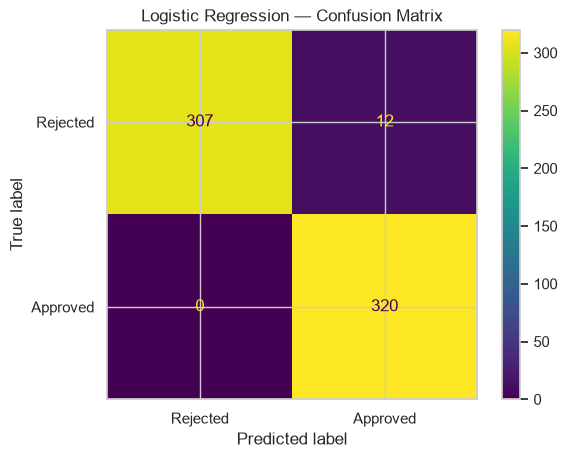

In [10]:
cm = confusion_matrix(
    y_test,
    logistic_predictions,
    labels=["Rejected", "Approved"],
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected", "Approved"],
)

disp.plot()
plt.title("Logistic Regression — Confusion Matrix")
plt.show()


## 11. Baseline 2 — Random Forest

Random Forest is a tree-based ensemble model.

Instead of relying on one decision tree, it builds many trees and combines their predictions.

It can learn nonlinear relationships and feature interactions that Logistic Regression may miss.

We keep the same preprocessing strategy so that the comparison is fair.


In [11]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
    )),
])

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)
approved_index = list(
    random_forest_model.named_steps["model"].classes_
).index("Approved")

rf_probabilities = random_forest_model.predict_proba(X_test)[:, approved_index]

rf_results = evaluate_classifier(
    "Random Forest",
    y_test,
    rf_predictions,
    rf_probabilities,
)

display(pd.DataFrame([rf_results]).round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.975,0.952,1.000,0.976,0.999


## 12. Compare the baseline models

Now we compare models using the same held-out test set.

The goal is not simply to select the model with the largest accuracy. We also care about:
- probability quality
- generalization
- interpretability
- suitability for SHAP explanations
- suitability for counterfactual analysis


In [12]:
results = pd.DataFrame([
    logistic_results,
    rf_results,
]).set_index("Model")

display(results.round(4))


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.981,0.964,1.000,0.982,1.000
Random Forest,0.975,0.952,1.000,0.976,0.999


## 13. The important experiment — remove Credit_History

EDA showed that `Credit_History` almost separates the target by itself.

Now we test that hypothesis.

We train another Logistic Regression model **without `Credit_History`**.

If performance collapses, that is evidence that the dataset's predictive structure is heavily concentrated in this feature.


In [13]:
features_without_credit = [
    feature for feature in categorical_features
    if feature != "Credit_History"
]

X_no_credit = df.drop(
    columns=["Loan_Status", "Loan_ID", "Credit_History"]
)

X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_no_credit,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

preprocessor_no_credit = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, features_without_credit),
])

logistic_no_credit = Pipeline([
    ("preprocessor", preprocessor_no_credit),
    ("model", LogisticRegression(max_iter=2000)),
])

logistic_no_credit.fit(X_train_nc, y_train_nc)

nc_predictions = logistic_no_credit.predict(X_test_nc)
nc_probabilities = logistic_no_credit.predict_proba(X_test_nc)[:, 1]

no_credit_results = evaluate_classifier(
    "Logistic Regression — Without Credit_History",
    y_test_nc,
    nc_predictions,
    nc_probabilities,
)

display(pd.DataFrame([no_credit_results]).round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression — Without Credit_History,0.507,0.508,0.506,0.507,0.497


## 14. Compare with and without Credit_History

This is one of the most important experiments in the project.

We are not removing `Credit_History` from the final system. We are measuring how much of the observed predictive performance depends on it.

A large performance gap means the dataset itself contains a dominant predictive signal.


In [14]:
comparison = pd.DataFrame([
    logistic_results,
    no_credit_results,
])

display(comparison.set_index("Model").round(4))


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.981,0.964,1.000,0.982,1.000
Logistic Regression — Without Credit_History,0.507,0.508,0.506,0.507,0.497


## 15. Baseline conclusions

Record the actual results from the cells above.

Questions to answer:

1. Which baseline performed better?
2. How large is the performance difference?
3. How much does performance change when `Credit_History` is removed?
4. Is high accuracy evidence that all features are equally informative?
5. What does this imply for LoanLens' explanation and counterfactual features?

### Important

We should not claim that the model has discovered a universal banking rule. These results describe the structure of **this dataset**.


## 16. Next stage

Once the baseline experiments are understood, the next stage is **model selection and explainability**.

Planned sequence:

`Baseline models`
→ `model diagnostics`
→ `SHAP explanations`
→ `similar application retrieval`
→ `constrained counterfactual engine`
→ `reliability/OOD analysis`
→ `FastAPI backend`

The final LoanLens model should be chosen based on more than raw accuracy: we also need it to support trustworthy explanations and useful decision analysis.
